PROJECT-
1.**STUDENT DATA ANALYSIS**

In [161]:
!pip install pandas matplotlib seaborn

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/Student.csv")
df.head()

,Reg_no,Attendance_percentage,Study_Hours_per_Day,English,Maths,Science,Kannada
0,10,90,5,98,95,99,100
1,11,80,4,89,80,79,88
2,12,30,1,45,34,23,44
3,13,40,3,67,76,75,77
4,14,50,2,55,58,60,59


In [163]:
print(df.head())
print(df.describe())

   Reg_no  Attendance_percentage  Study_Hours_per_Day  English  Maths  \
0      10                     90                    5       98     95   
1      11                     80                    4       89     80   
2      12                     30                    1       45     34   
3      13                     40                    3       67     76   
4      14                     50                    2       55     58   

   Science  Kannada  
0       99      100  
1       79       88  
2       23       44  
3       75       77  
4       60       59  
          Reg_no  Attendance_percentage  Study_Hours_per_Day    English  \
count   5.000000               5.000000             5.000000   5.000000   
mean   12.000000              58.000000             3.000000  70.800000   
std     1.581139              25.884358             1.581139  22.365151   
min    10.000000              30.000000             1.000000  45.000000   
25%    11.000000              40.000000             2.

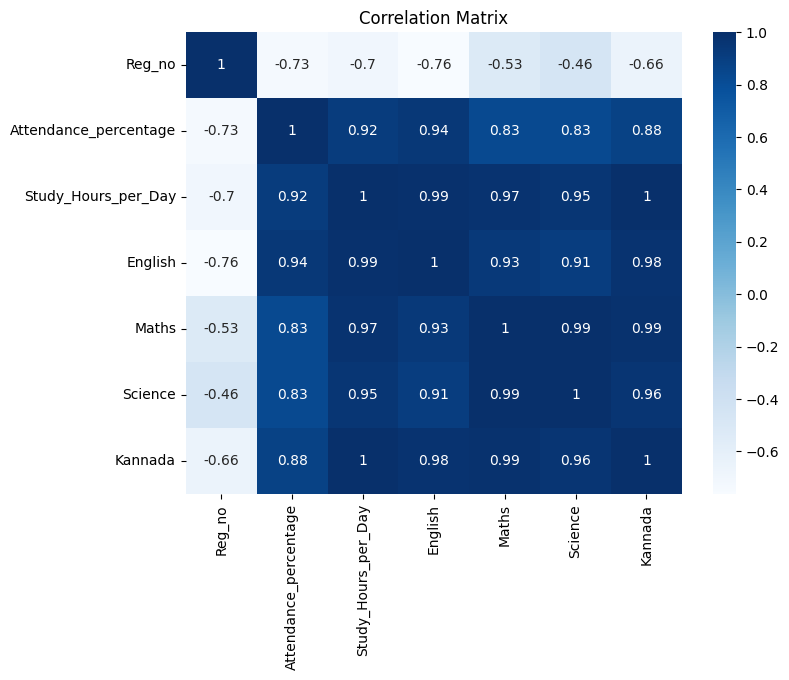

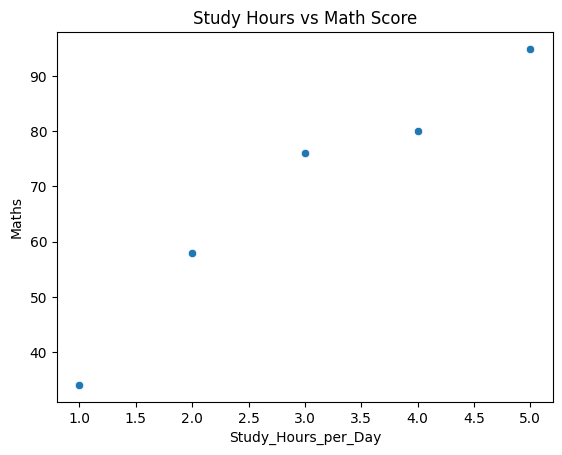

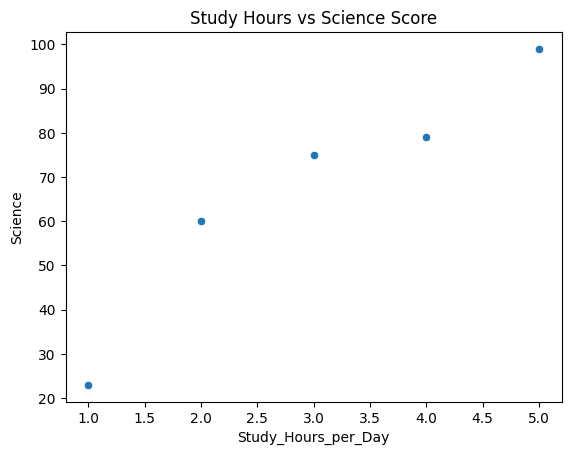

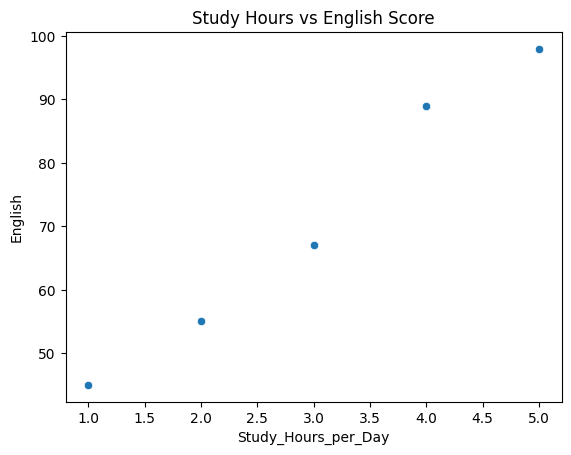

In [164]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()
plt.figure()
sns.scatterplot(x='Study_Hours_per_Day', y='Maths', data=df)
plt.title("Study Hours vs Math Score")
plt.show()
plt.figure()
sns.scatterplot(x='Study_Hours_per_Day', y='Science', data=df)
plt.title("Study Hours vs Science Score")
plt.show()
plt.figure()
sns.scatterplot(x='Study_Hours_per_Day', y='English', data=df)
plt.title("Study Hours vs English Score")
plt.show()

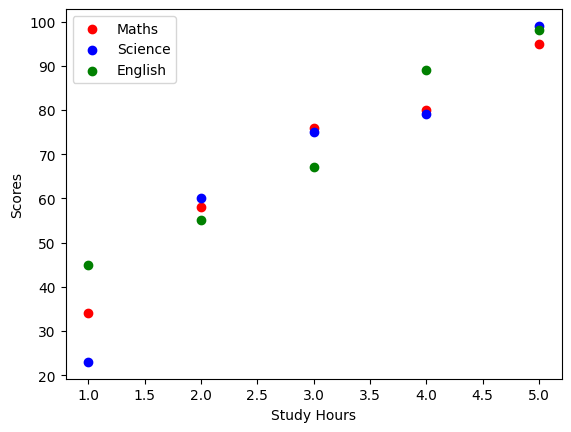

In [165]:
import matplotlib.pyplot as plt
x = df['Study_Hours_per_Day']
y1 = df['Maths']
y2 = df['Science']
y3 = df['English']
plt.scatter(x, y1, color='red', label='Maths')
plt.scatter(x, y2, color='blue', label='Science')
plt.scatter(x, y3, color='green', label='English')
plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.legend()
plt.show()

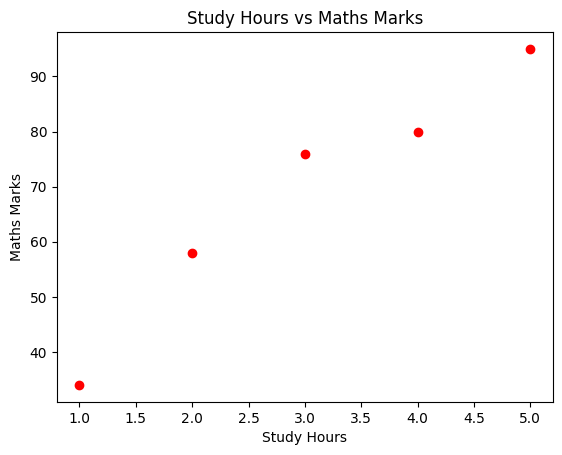

In [166]:
import matplotlib.pyplot as plt
x = df['Study_Hours_per_Day']
y = df['Maths']
plt.scatter(x, y, color='red')
plt.xlabel("Study Hours")
plt.ylabel("Maths Marks")
plt.title("Study Hours vs Maths Marks")
plt.show()

0    97.333333
1    82.666667
2    34.000000
3    72.666667
4    57.666667
Name: average_score, dtype: float64


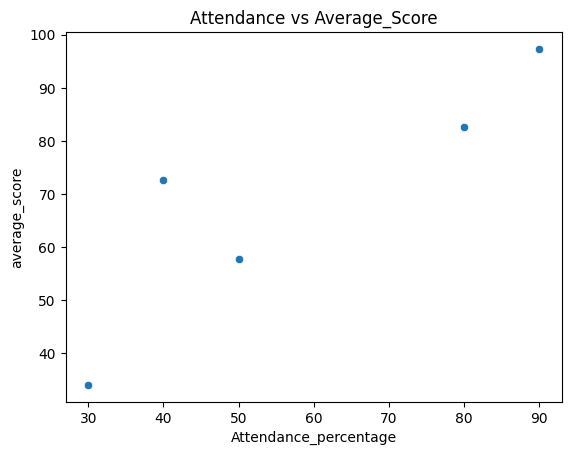

In [167]:
plt.figure()
df['average_score'] = df[['Maths','English','Science']].mean(axis=1)
print(df.average_score)
sns.scatterplot(x='Attendance_percentage', y='average_score', data=df)
plt.title("Attendance vs Average_Score")
plt.show()

In [168]:
df['average_score'] = df[['Maths','English','Science']].mean(axis=1)
print(df.average_score)
df['At_Risk'] = (
    (df['Attendance_percentage'] < 40) |
    (df['Study_Hours_per_Day'] < 1) |
    (df['average_score'] < 50))

0    97.333333
1    82.666667
2    34.000000
3    72.666667
4    57.666667
Name: average_score, dtype: float64


In [169]:
df['At_Risk'] = (
    (df['Attendance_percentage'] < 40) |
    (df['Study_Hours_per_Day'] < 1) |
    (df['average_score'] < 50)
)

In [170]:
at_risk_students = df[df['At_Risk'] == True]
print("the students below score 50 are:",at_risk_students)

the students below score 50 are:    Reg_no  Attendance_percentage  Study_Hours_per_Day  English  Maths  \
2      12                     30                    1       45     34   

   Science  Kannada  average_score  At_Risk  
2       23       44           34.0     True  


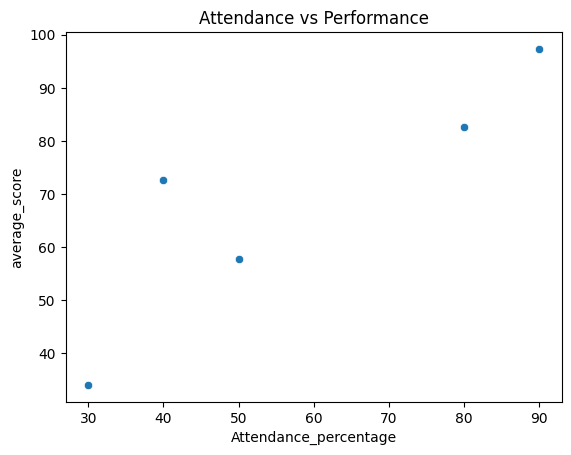

In [171]:
plt.figure()
sns.scatterplot(x='Attendance_percentage', y='average_score', data=df)
plt.title("Attendance vs Performance")
plt.show()

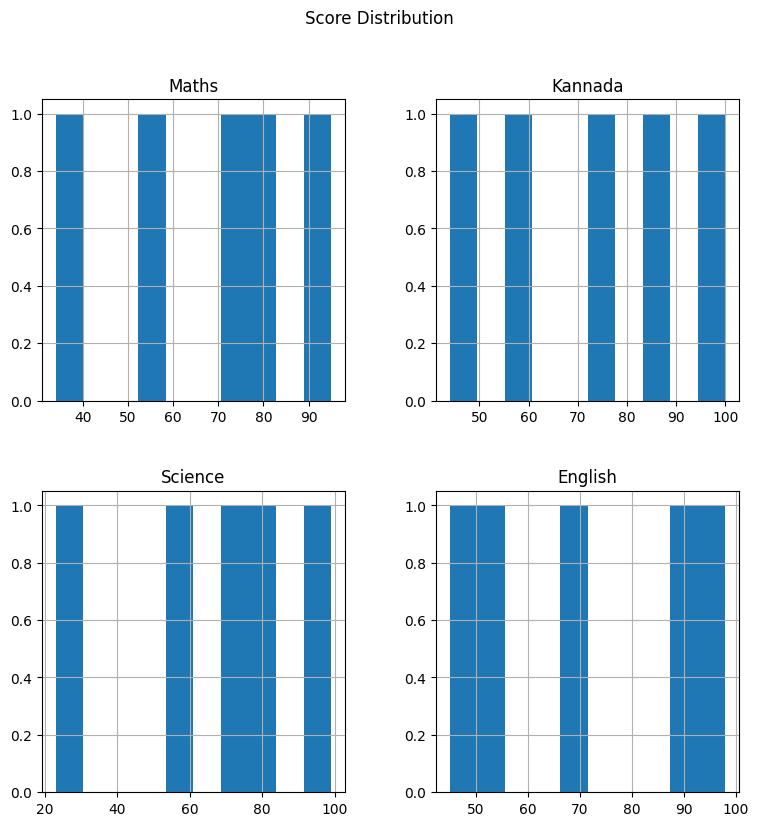

In [172]:
df[['Maths','Kannada','Science','English']].hist(figsize=(9,9))
plt.suptitle("Score Distribution")
plt.show()

array([[<Axes: title={'center': 'Maths'}>,
        <Axes: title={'center': 'English'}>],
       [<Axes: title={'center': 'Science'}>,
        <Axes: title={'center': 'Kannada'}>]], dtype=object)

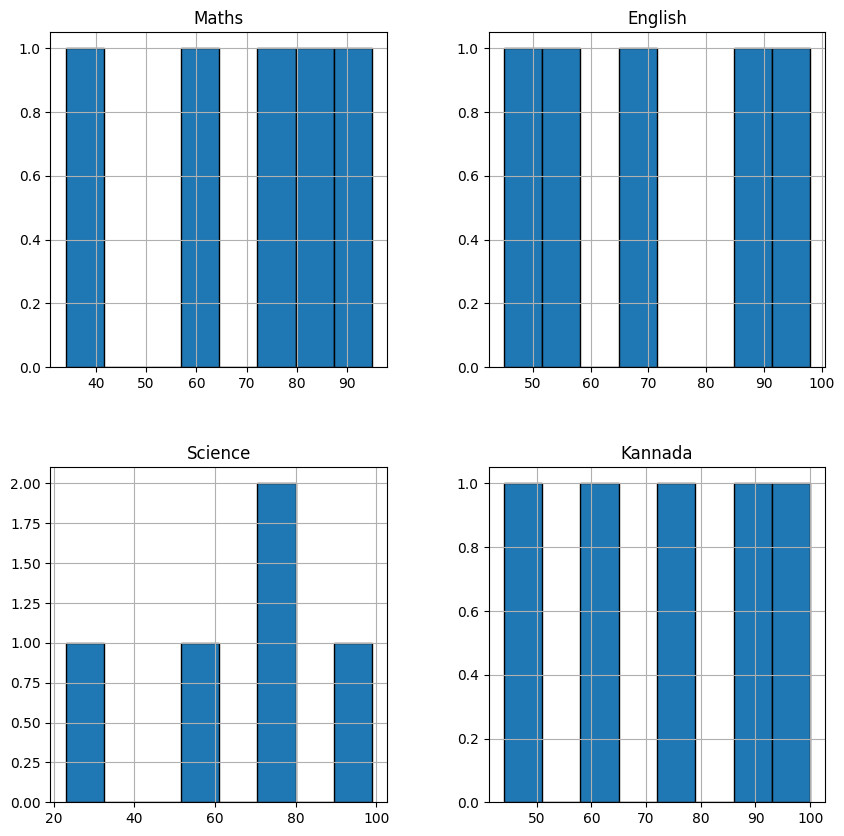

In [173]:
df[['Maths','English','Science','Kannada']].hist(
    bins=8,
    figsize=(10,10),
    edgecolor='black'
)

2.**HOUSE PRICE PREDICTION**

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
data = {
    "Area": [1009, 1200, 1500, 1800, 2000, 2500, 3000],
    "Rooms": [2, 2, 3, 3, 4, 4, 5],
    "Age": [10, 8, 7, 5, 4, 3, 2],
    "Price": [200000, 250000, 300000, 350000,
              400000, 500000, 600000]
}
df = pd.DataFrame(data)
print("===== HOUSE DATA =====")
print(df)

===== HOUSE DATA =====
   Area  Rooms  Age   Price
0  1009      2   10  200000
1  1200      2    8  250000
2  1500      3    7  300000
3  1800      3    5  350000
4  2000      4    4  400000
5  2500      4    3  500000
6  3000      5    2  600000


In [175]:
X = df[["Area", "Rooms", "Age"]]
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
print("\n===== MODEL RESULTS =====")
print("RMSE:", rmse)
print("R2 Score:", r2)


===== MODEL RESULTS =====
RMSE: 12289.502354512331
R2 Score: 0.7583490110054973


In [176]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
print("\n===== ACTUAL VS PREDICTED =====")
print(results)


===== ACTUAL VS PREDICTED =====
   Actual Price  Predicted Price
0        200000    200259.146341
1        250000    232621.951220


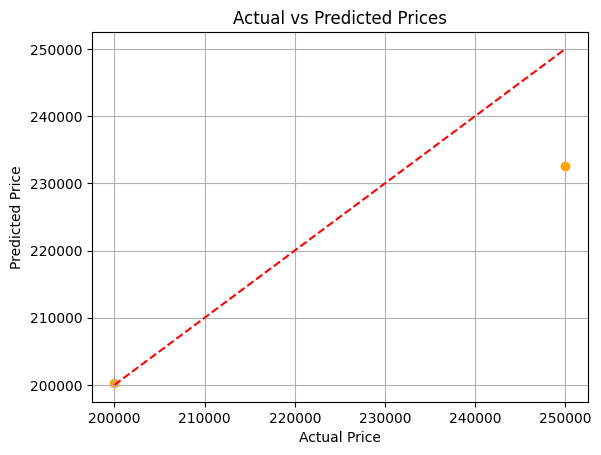

In [177]:
plt.scatter(y_test, y_pred, color="orange")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red', linestyle='--')
plt.show()

In [178]:
new_house = [[2200, 4, 3]]
predicted_price = model.predict(new_house)
print("\nPredicted House Price =", predicted_price[0])


Predicted House Price = 436585.3658536583


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


3.**IPL DATA ANALYSIS**

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("IPL.csv")
print(df.head())
print(df.columns)

   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed dismissal_kind fielder  
0

In [180]:
df.dropna(subset=['batter', 'bowler', 'batsman_runs'], inplace=True)

In [181]:
top_batters = (
    df.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop Batsmen:")
print(top_batters)


Top Batsmen:
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64



Top Batsmen:
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


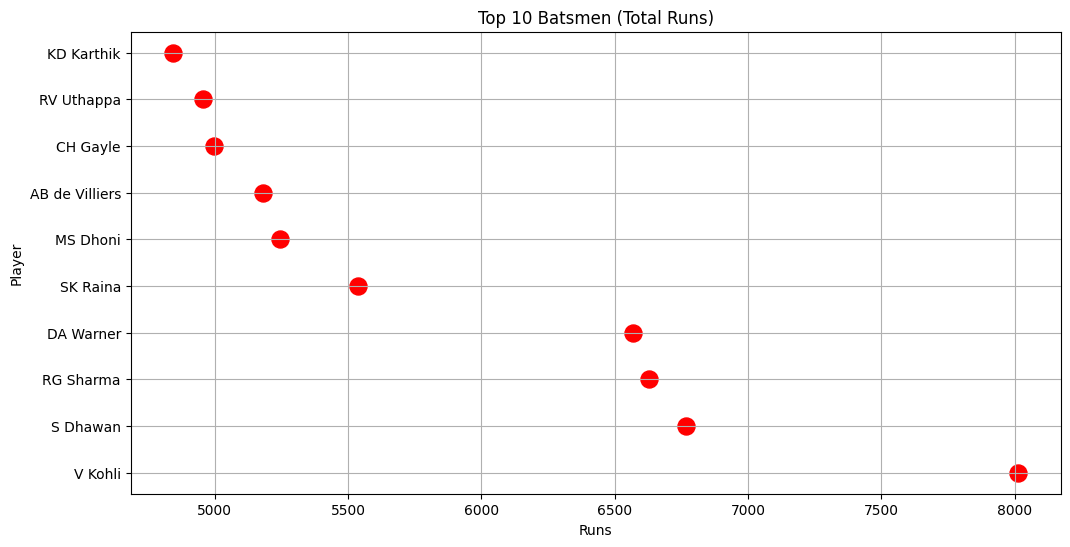

In [182]:
print("\nTop Batsmen:")
print(top_batters)

plt.figure(figsize=(12,6))
plt.scatter(
    top_batters.values,
    top_batters.index,
    color='red',
    s=150
)
plt.title("Top 10 Batsmen (Total Runs)")
plt.xlabel("Runs")
plt.ylabel("Player")
plt.grid(True)
plt.show()

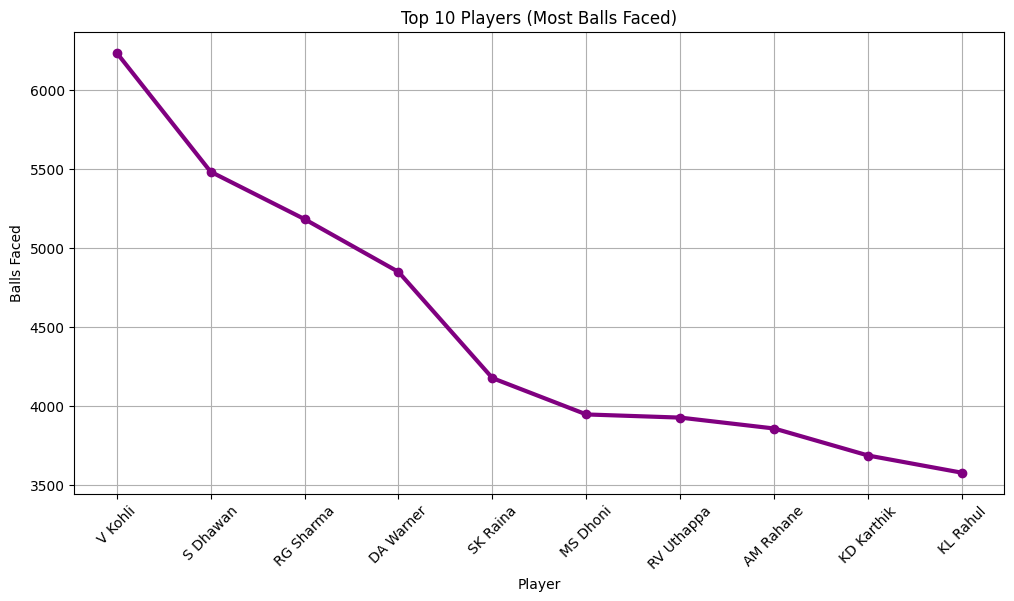

In [183]:
balls_faced = df['batter'].value_counts().head(10)
plt.figure(figsize=(12,6))
plt.plot(
    balls_faced.index,
    balls_faced.values,
    marker='o',
    color='purple',
    linewidth=3
)
plt.title("Top 10 Players (Most Balls Faced)")
plt.xlabel("Player")
plt.ylabel("Balls Faced")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

/tmp/ipykernel_2254/1072068761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


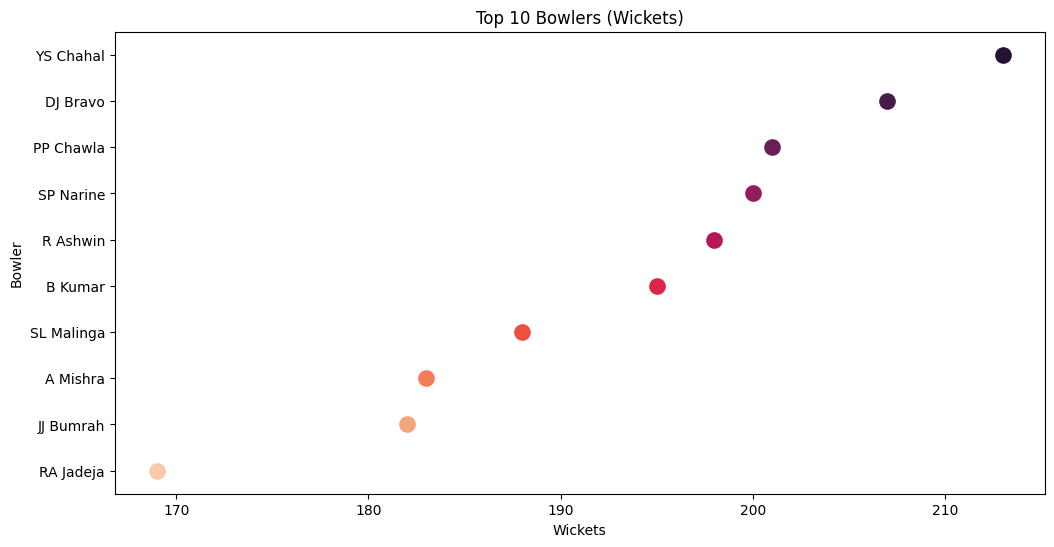

In [184]:
plt.figure(figsize=(12,6))
sns.stripplot(
    x=top_bowlers.values,
    y=top_bowlers.index,
    size=12,
    palette="rocket"
)
plt.title("Top 10 Bowlers (Wickets)")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()



Top Bowlers:
bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: count, dtype: int64


/tmp/ipykernel_2254/1816795665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


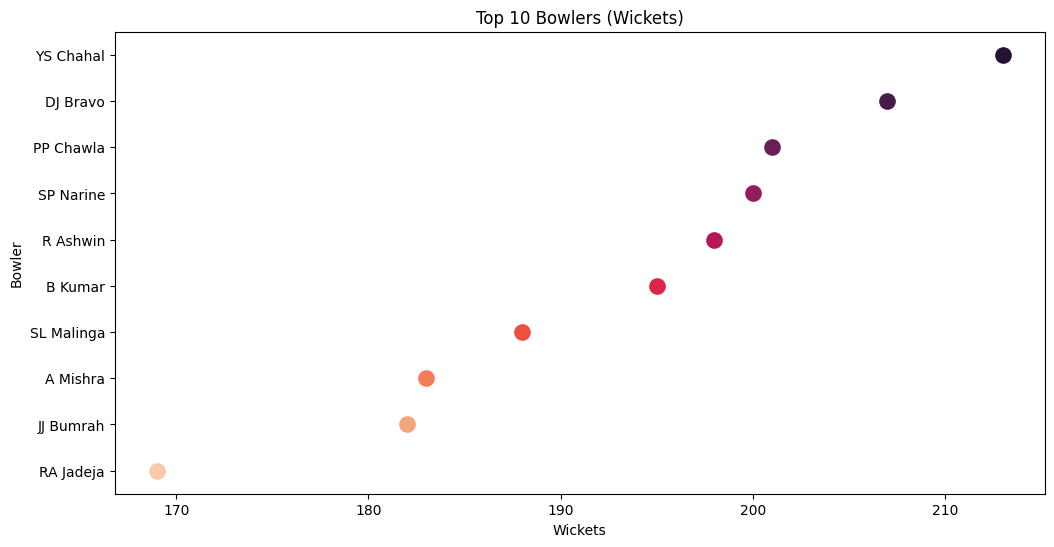

In [185]:
wickets_df = df[df['is_wicket'] == 1]
top_bowlers = wickets_df['bowler'].value_counts().head(10)
print("\nTop Bowlers:")
print(top_bowlers)

plt.figure(figsize=(12,6))
sns.stripplot(
    x=top_bowlers.values,
    y=top_bowlers.index,
    size=12,
    palette="rocket"
)
plt.title("Top 10 Bowlers (Wickets)")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()

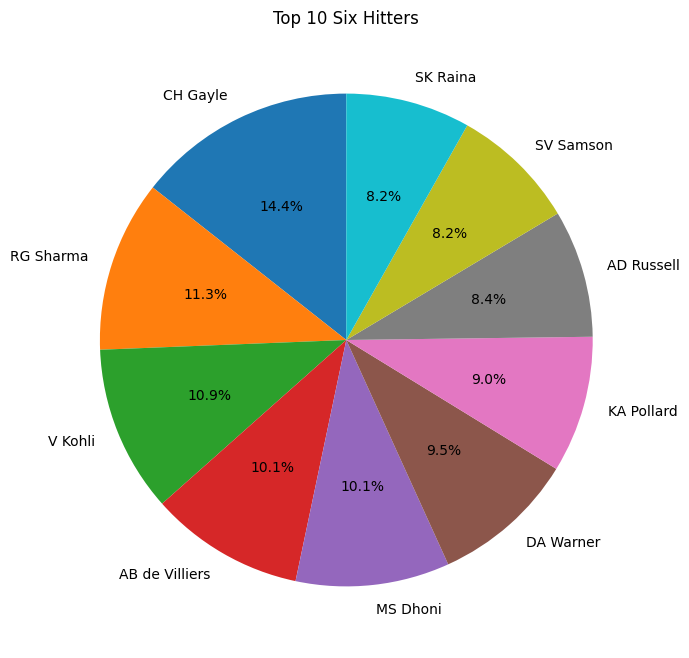

In [186]:
sixes = df[df['batsman_runs'] == 6]

top_six_hitters = sixes['batter'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_six_hitters.values,
    labels=top_six_hitters.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 10 Six Hitters")

plt.show()

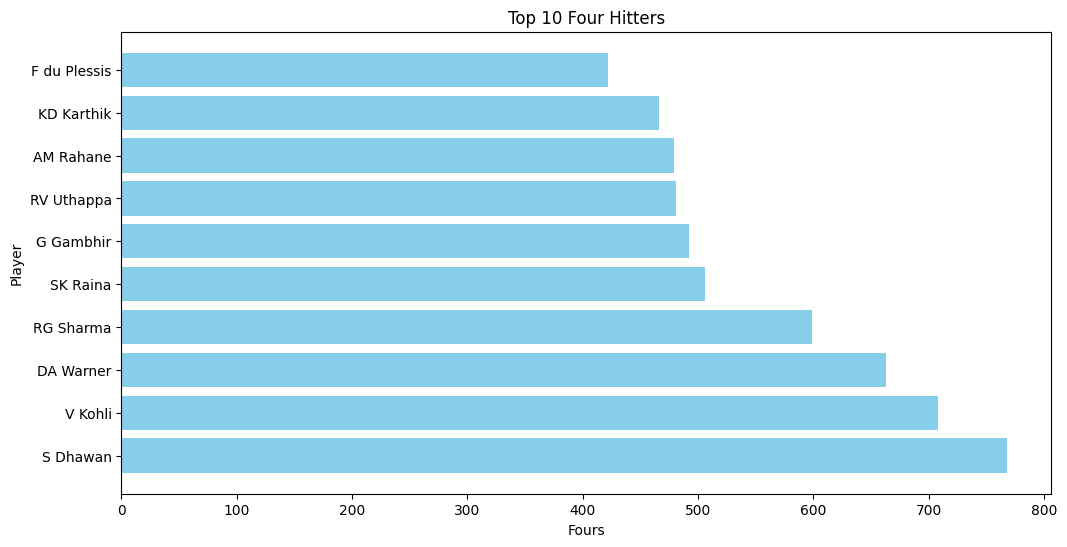

In [187]:
fours = df[df['batsman_runs'] == 4]

top_four_hitters = fours['batter'].value_counts().head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_four_hitters.index,
    top_four_hitters.values,
    color='skyblue'
)

plt.title("Top 10 Four Hitters")
plt.xlabel("Fours")
plt.ylabel("Player")

plt.show()

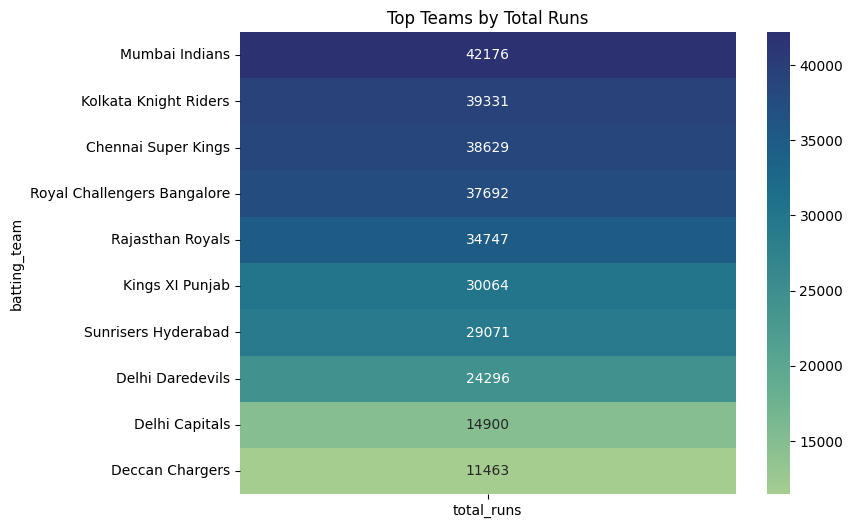

In [188]:
team_runs = (
    df.groupby('batting_team')['total_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

team_runs_df = pd.DataFrame(team_runs)

plt.figure(figsize=(8,6))

sns.heatmap(
    team_runs_df,
    annot=True,
    cmap='crest',
    fmt='g'
)

plt.title("Top Teams by Total Runs")

plt.show()

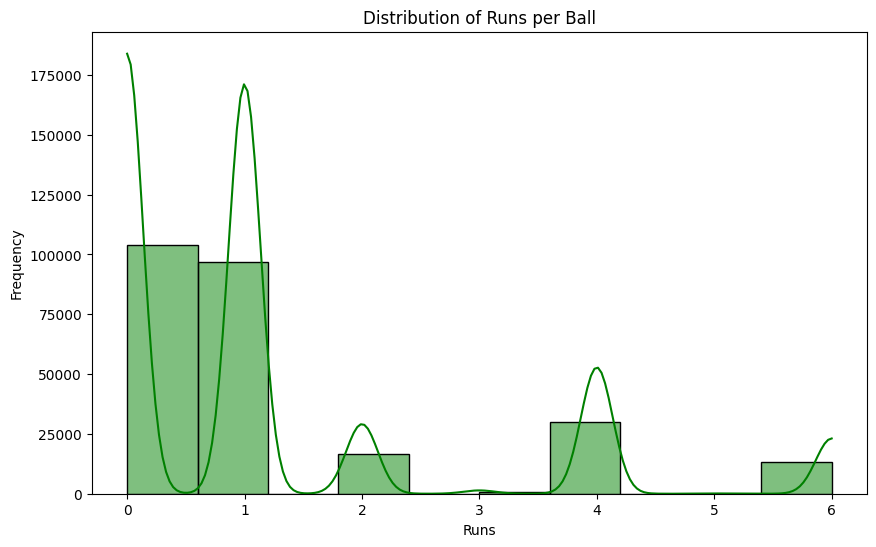

In [189]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['batsman_runs'],
    bins=10,
    kde=True,
    color='green'
)
plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()


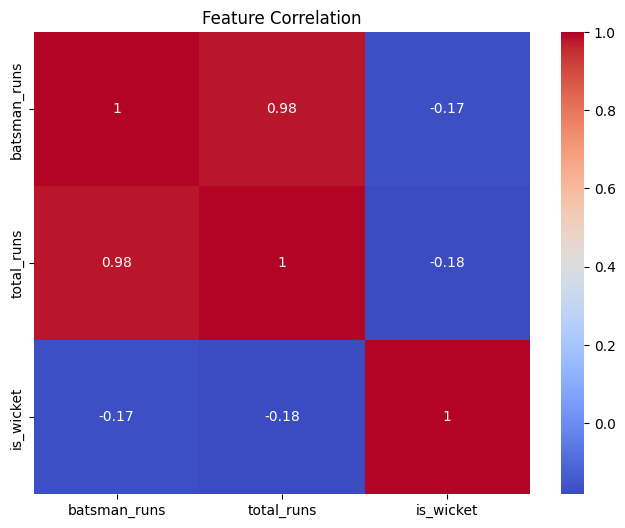


Analysis Completed Successfully!


In [190]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['batsman_runs', 'total_runs', 'is_wicket']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation")
plt.show()

df.to_csv("cleaned_deliveries.csv", index=False)
print("\nAnalysis Completed Successfully!")